In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline 

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load Online Retail dataset

df = pd.read_excel("Online Retail.xlsx")
print("Dataset Shape:", df.shape)
# Display first 5 rows
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
# Inspect the data

print("Number of rows and columns:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
df.describe()


Number of rows and columns: (392692, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicate Rows:
0

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [6]:
# Remove rows without CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantity and price
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove duplicate rows
df = df.drop_duplicates()

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (392692, 8)


In [ ]:
# This confirms that the InvoiceDate column has been correctly converted to a date/time format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[ns]


In [8]:
# Create TotalAmount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [9]:
# Create the reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [13]:
# Calculate RFM
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

# Here,
# Recency = how recently the customer purchased
# Frequency = how many different orders they made
# Monetary = how much they spent"""

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [17]:
# Check RFM statistics
print("Average Purchase Value:", df["TotalAmount"].mean())

print("Average Purchase Frequency:", rfm["Frequency"].mean())

print("Average Customer Monetary Value:", rfm["Monetary"].mean())

print("\nRFM Statistics:")
display(rfm.describe())

Average Purchase Value: 22.6314997351614
Average Purchase Frequency: 4.272014753342554
Average Customer Monetary Value: 2048.688080682342

RFM Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


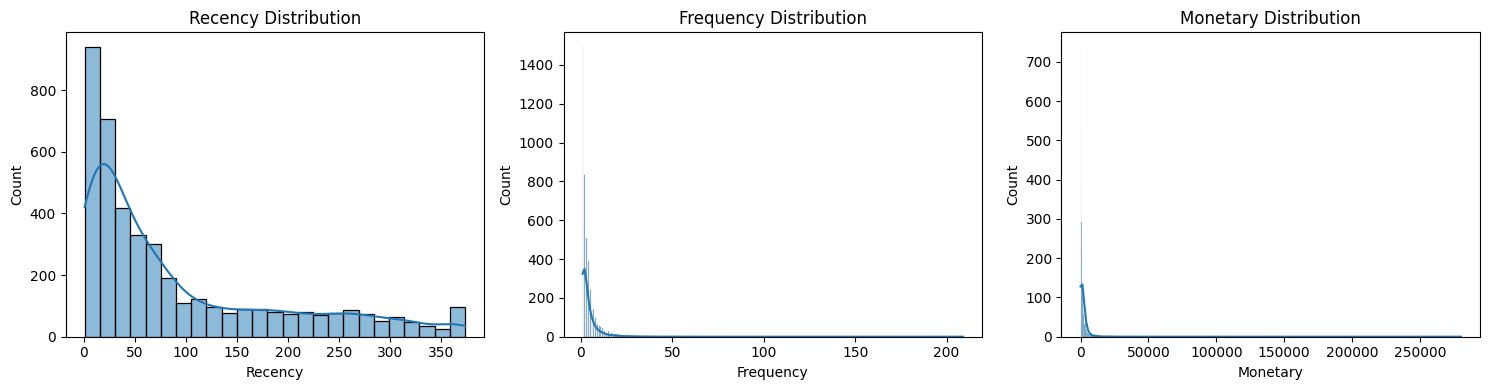

In [15]:
# Visualize RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

### Observation

The RFM distributions show differences in customer purchasing behaviour.
Customers vary in how recently they purchased, how frequently they order,
and how much they spend.

In [ ]:
#normalization/standardization
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


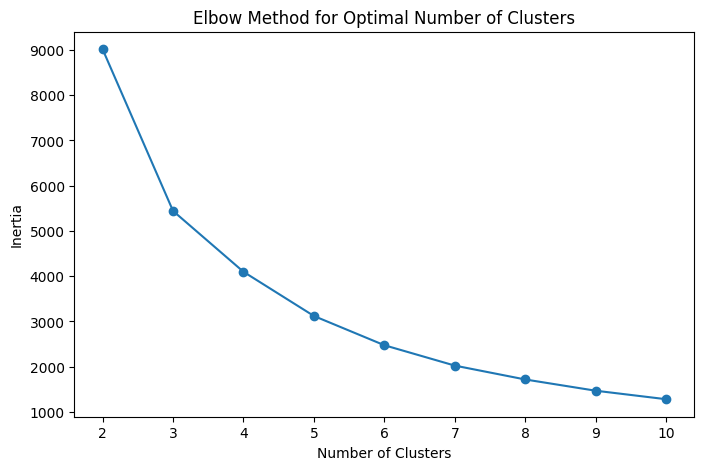

In [19]:
# Elbow Method 
# The Elbow Method is used to find the best number of clusters (K) before applying K-Means

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [20]:
# K-Means clustering
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [ ]:
# Cluster profiling
# Cluster profiling means understanding what type of customers are present in each cluster after K-Means creates the groups

cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


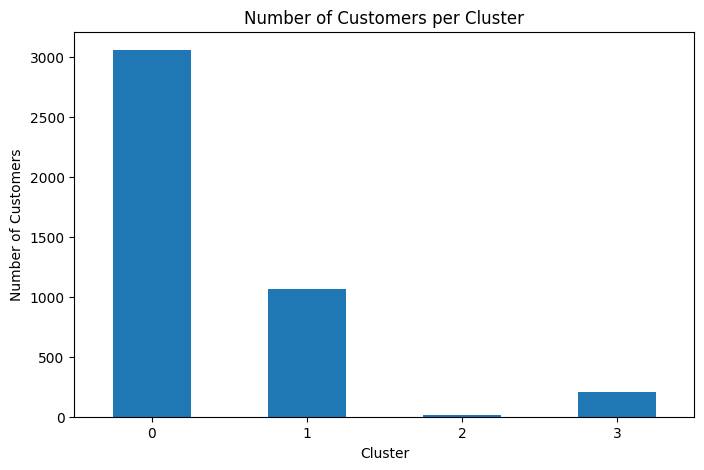

In [22]:
# Customers per cluster
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

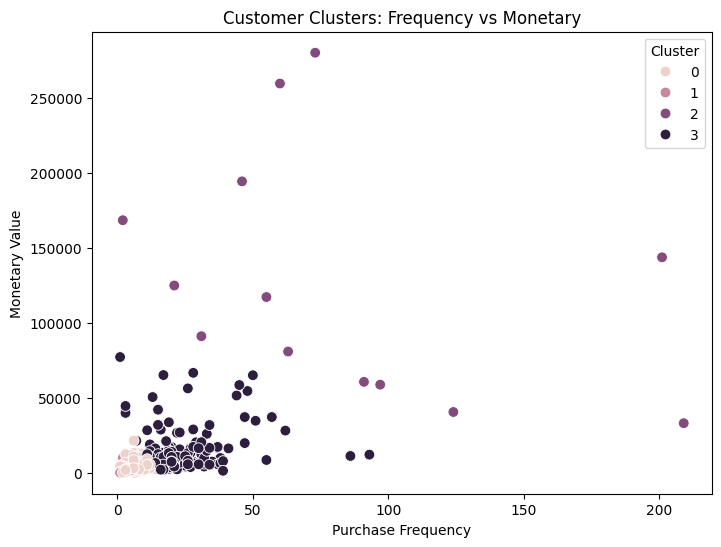

In [23]:
# Visualization 1
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    s=60
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

### Observation

The scatter plot shows how customer clusters differ according to
purchase frequency and monetary value. Customers belonging to
different clusters show different purchasing patterns.

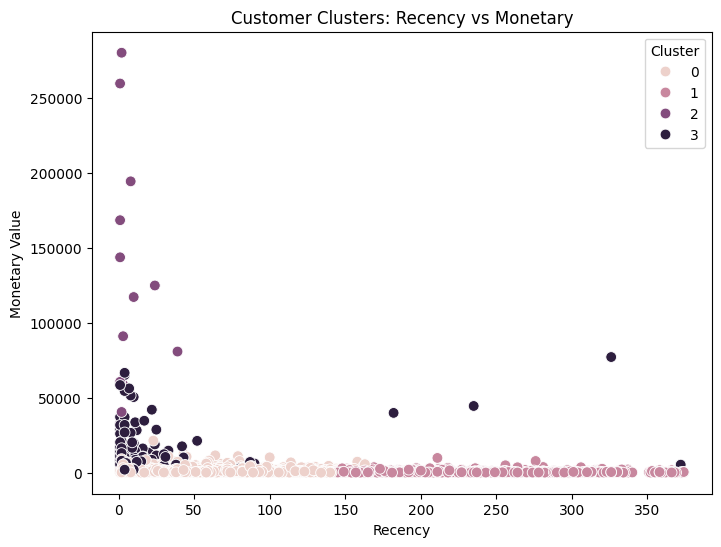

In [24]:
# Visualization 2
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    s=60
)

plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.show()

### Observation

The plot shows the relationship between how recently customers
purchased and how much they spent. The clusters help identify
different customer behaviours.

## Customer Segment Interpretation

Cluster 0:
Analyse the Recency, Frequency and Monetary values to identify
the purchasing behaviour of this group.

Cluster 1:
Analyse the average RFM values to determine whether these customers
are frequent, high-value or less active customers.

Cluster 2:
This group can be targeted according to its purchasing behaviour
and spending level.

Cluster 3:
This group can be targeted with suitable retention or
re-engagement campaigns depending on its RFM values.

## Marketing Recommendations

1. High-value customers:
   Provide loyalty rewards, exclusive offers and early access to new products.

2. Frequent customers:
   Use loyalty programs and personalized recommendations to maintain engagement.

3. Low-frequency customers:
   Offer discounts and targeted promotions to encourage repeat purchases.

4. Inactive customers:
   Use re-engagement campaigns and special offers to encourage them to return.

In [25]:
# save output
rfm.to_csv("customer_segments.csv")

print("Customer segmentation completed successfully!")

Customer segmentation completed successfully!
